# Clustering and Pattern Analysis

Cluster the annotated seqlets, turn each cluster into a consensus motif, and plot the result.
`tfmindi` runs all of this on the GPU when one is available.

In [1]:
import tfmindi as tm

# Auto-detected; override with tm.set_backend("cpu"/"gpu") or the TFMINDI_BACKEND env var.
print(f"backend: {tm.get_backend()}")
print(f"gpu: {tm.is_gpu_available()}")

/data/groups/vib.ai/stein.aerts/dabaffy/software/conda_envs/tfmindi/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


backend: gpu
gpu: True


## Load preprocessed data from previous tutorial

In [2]:
adata = tm.load_h5ad("tutorial_data/seqlets.h5ad")
print(adata)
# Resolution the seqlets were annotated at in tutorial 01; it names the annotation columns.
res = 5.0

AnnData object with n_obs × n_vars = 582915 × 4780
    obs: 'example_idx', 'start', 'end', 'attribution', 'score', 'example_oh_idx', 'example_contrib_idx', 'cell_type', 'predicted_5.0_predicted_cluster', 'predicted_5.0_predicted_cluster_score', 'predicted_5.0_predicted_family', 'predicted_5.0_predicted_family_reranked', 'predicted_5.0_predicted_family_reranked_score', 'predicted_5.0_predicted_family_no_cl'
    var: 'motif_ppm'
    uns: 'unique_examples'
    obsm: 'X_ref_proj_20'
    layers: None (.X)


## Embed and cluster seqlets

{func}`~tfmindi.tl.embed_and_cluster` runs PCA, builds the neighbourhood graph, computes the t-SNE
embedding and clusters with Leiden. All four steps use the GPU when one is available.

In [3]:
tm.tl.embed_and_cluster(adata, resolution=2.5)

Using GPU-accelerated backend for clustering operations...
Computing PCA...
Computing neighborhood graph...
Computing t-SNE embedding...
[2026-08-26 05:49:58.514] [CUML] [warning] # of Nearest Neighbors should be at least 3 * perplexity. Your results might be a bit strange...
Performing Leiden clustering with resolution 2.5...
Clustering complete. Found 67 clusters.


## Plotting

Everything for inspecting seqlets lives in the `tfmindi.pl` module — for example
{func}`~tfmindi.pl.tsne`, which draws seqlet clusters in t-SNE space.

```{note}
All `tfmindi.pl` functions pass their layout keywords to {func}`~tfmindi.pl.render_plot`
(`width`, `height`, `title`, `save_path`, ...). Look there to customize a plot; don't call it directly.
```

### Visualize TF family annotations

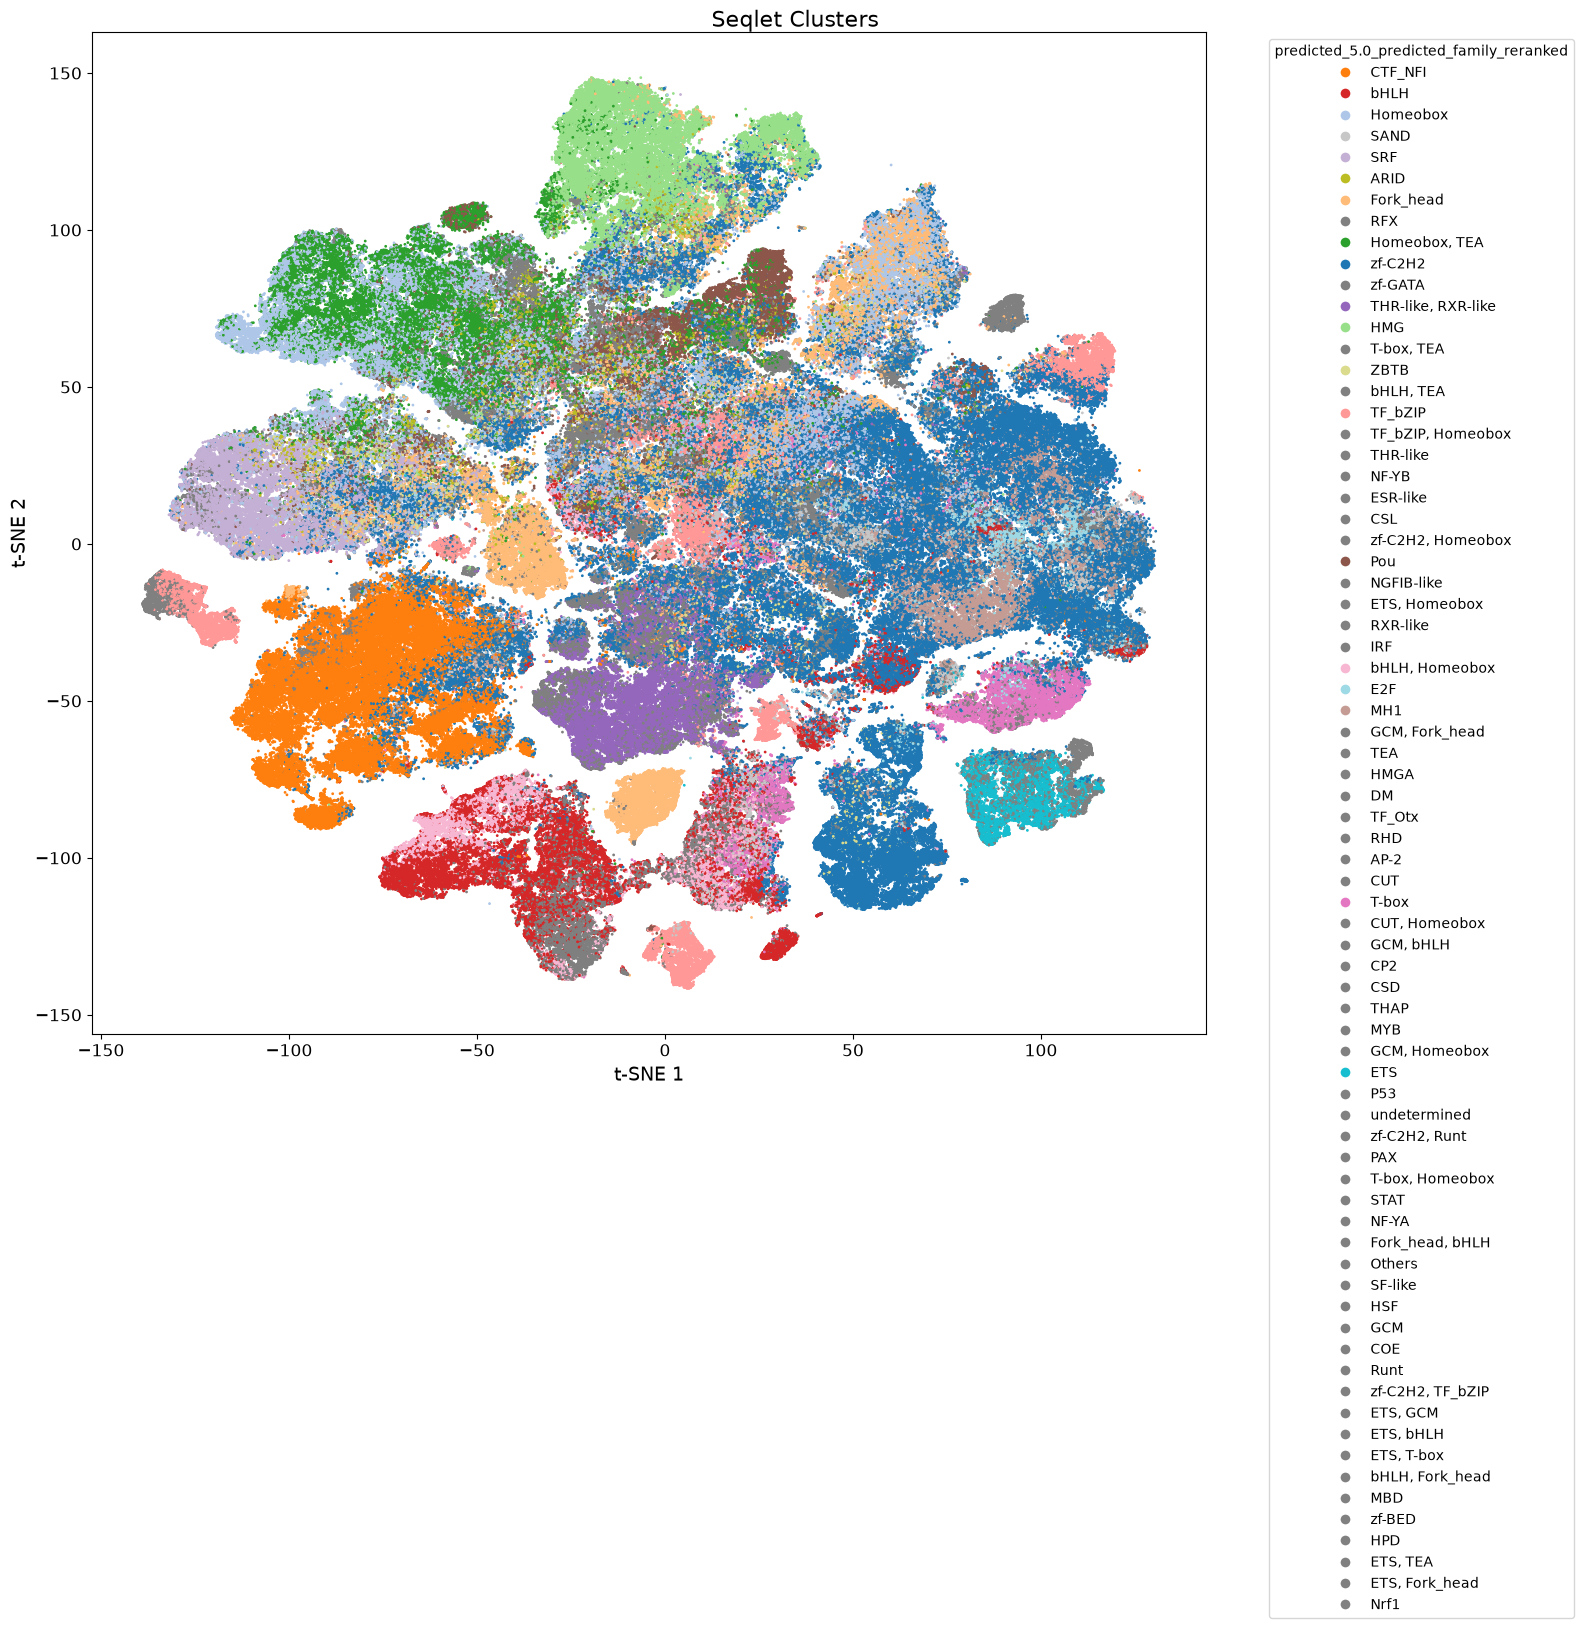

In [4]:
%matplotlib inline

import matplotlib as mpl
import matplotlib.colors as mcolors

# Colour the 20 most frequent families with tab20 and grey out the rest.
cmap = mpl.colormaps["tab20"]
family_col = f"predicted_{res}_predicted_family_reranked"

top_20_fam = adata.obs[family_col].value_counts().head(20).index
fam_colors: dict[str, str] = {
    fam: mcolors.to_hex(cmap(i / cmap.N), keep_alpha=True) if fam in top_20_fam else "gray"
    for i, fam in enumerate(adata.obs[family_col].value_counts().index)
}
adata.uns[f"{family_col}_colors"] = fam_colors

tm.pl.tsne(adata, color_by=family_col, s=1, alpha=1, width=16, height=15)

### Visualize TF-MINDI motif collection cluster assignment probability

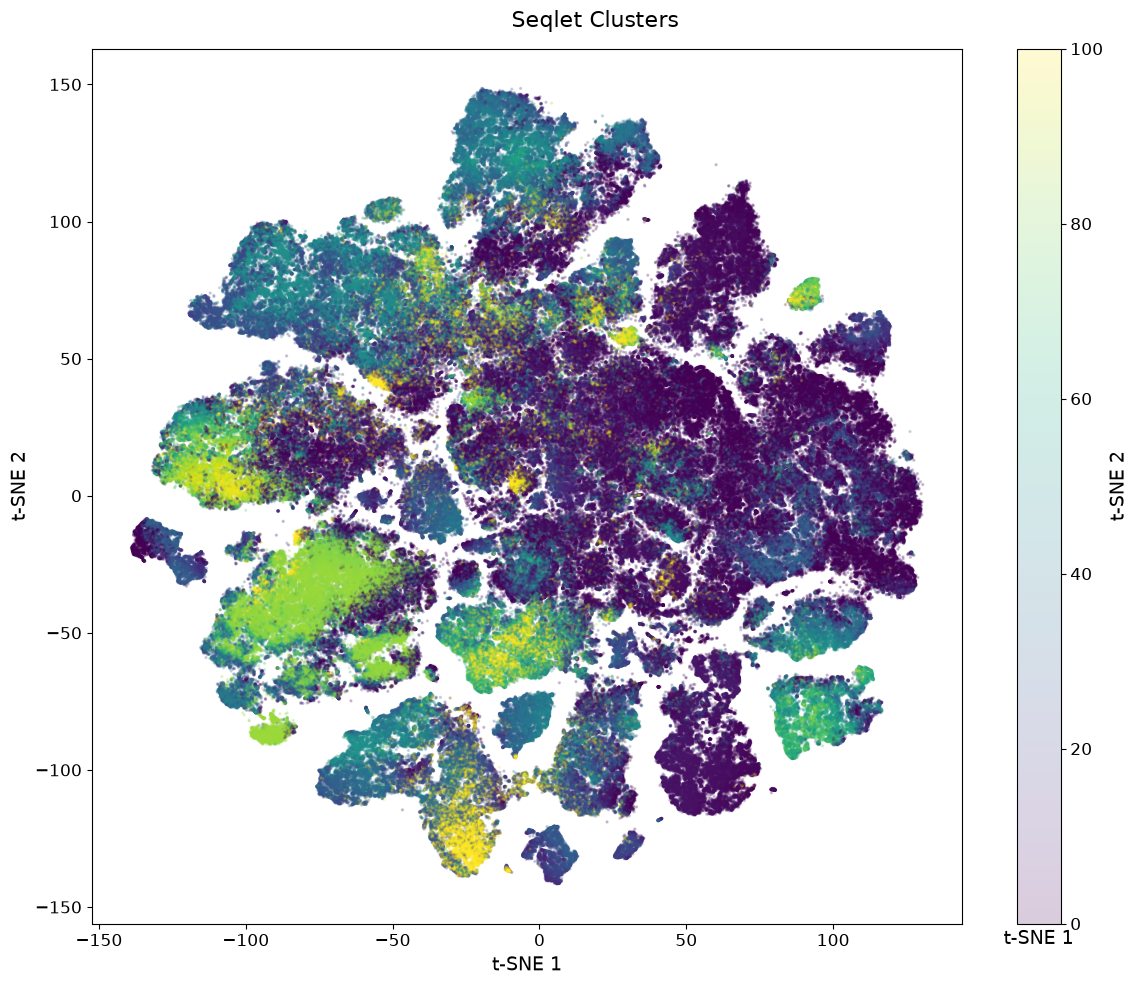

In [5]:
tm.pl.tsne(adata, color_by=f"predicted_{res}_predicted_family_reranked_score", s=2, alpha=0.2, width=12, height=10)

### Plot leiden clusters

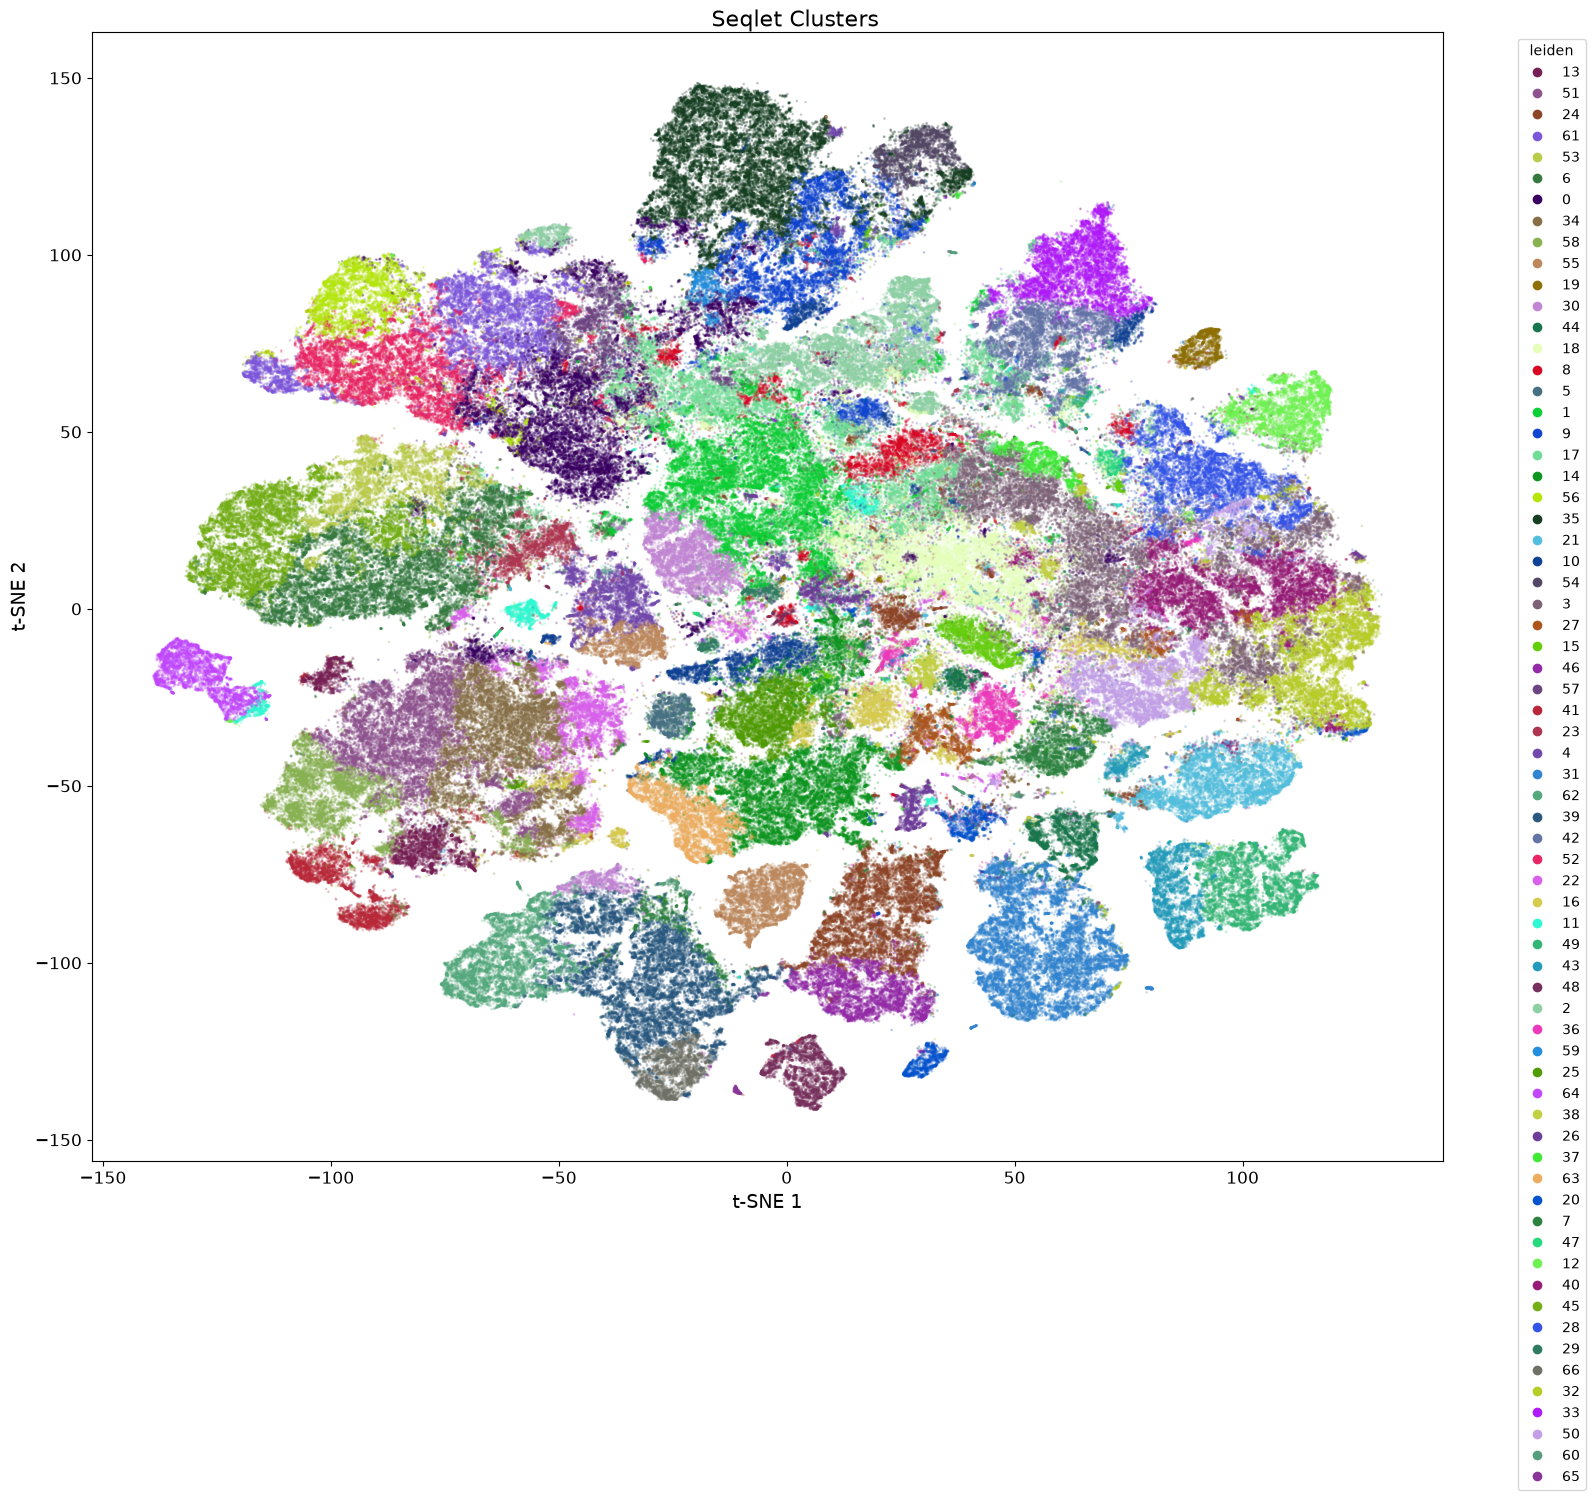

In [6]:
tm.pl.tsne(adata, color_by="leiden", s=1, alpha=0.2, width=16, height=15)

### Consensus logos per cluster

Next we build a consensus {class}`tfmindi.Pattern` per cluster of seqlets. Save and load them with
{func}`tfmindi.save_patterns` / {func}`tfmindi.load_patterns`.

`annotation_col` decides what the logos can be grouped by later, so pass the family-only column
rather than the `<cluster>|<family>` one.

In [7]:
patterns = tm.tl.create_patterns(
    adata,
    method="tomtom",  # options: 'kmer', 'tomtom'
    max_n=1000,  # sample up to n seqlets per cluster to speed things up
    # The family-only column: the `predicted_{res}_predicted_family` one prefixes the motif
    # collection's own cluster id, which would make almost every annotation unique.
    annotation_col=f"predicted_{res}_predicted_family_reranked",
)

Creating patterns for 67 clusters...


Plot the logo of each cluster. Titles read `Cluster <leiden id> - <TF family>`, where the leiden id
is the seqlet cluster from `embed_and_cluster` and the family is the most common annotation among
its seqlets.

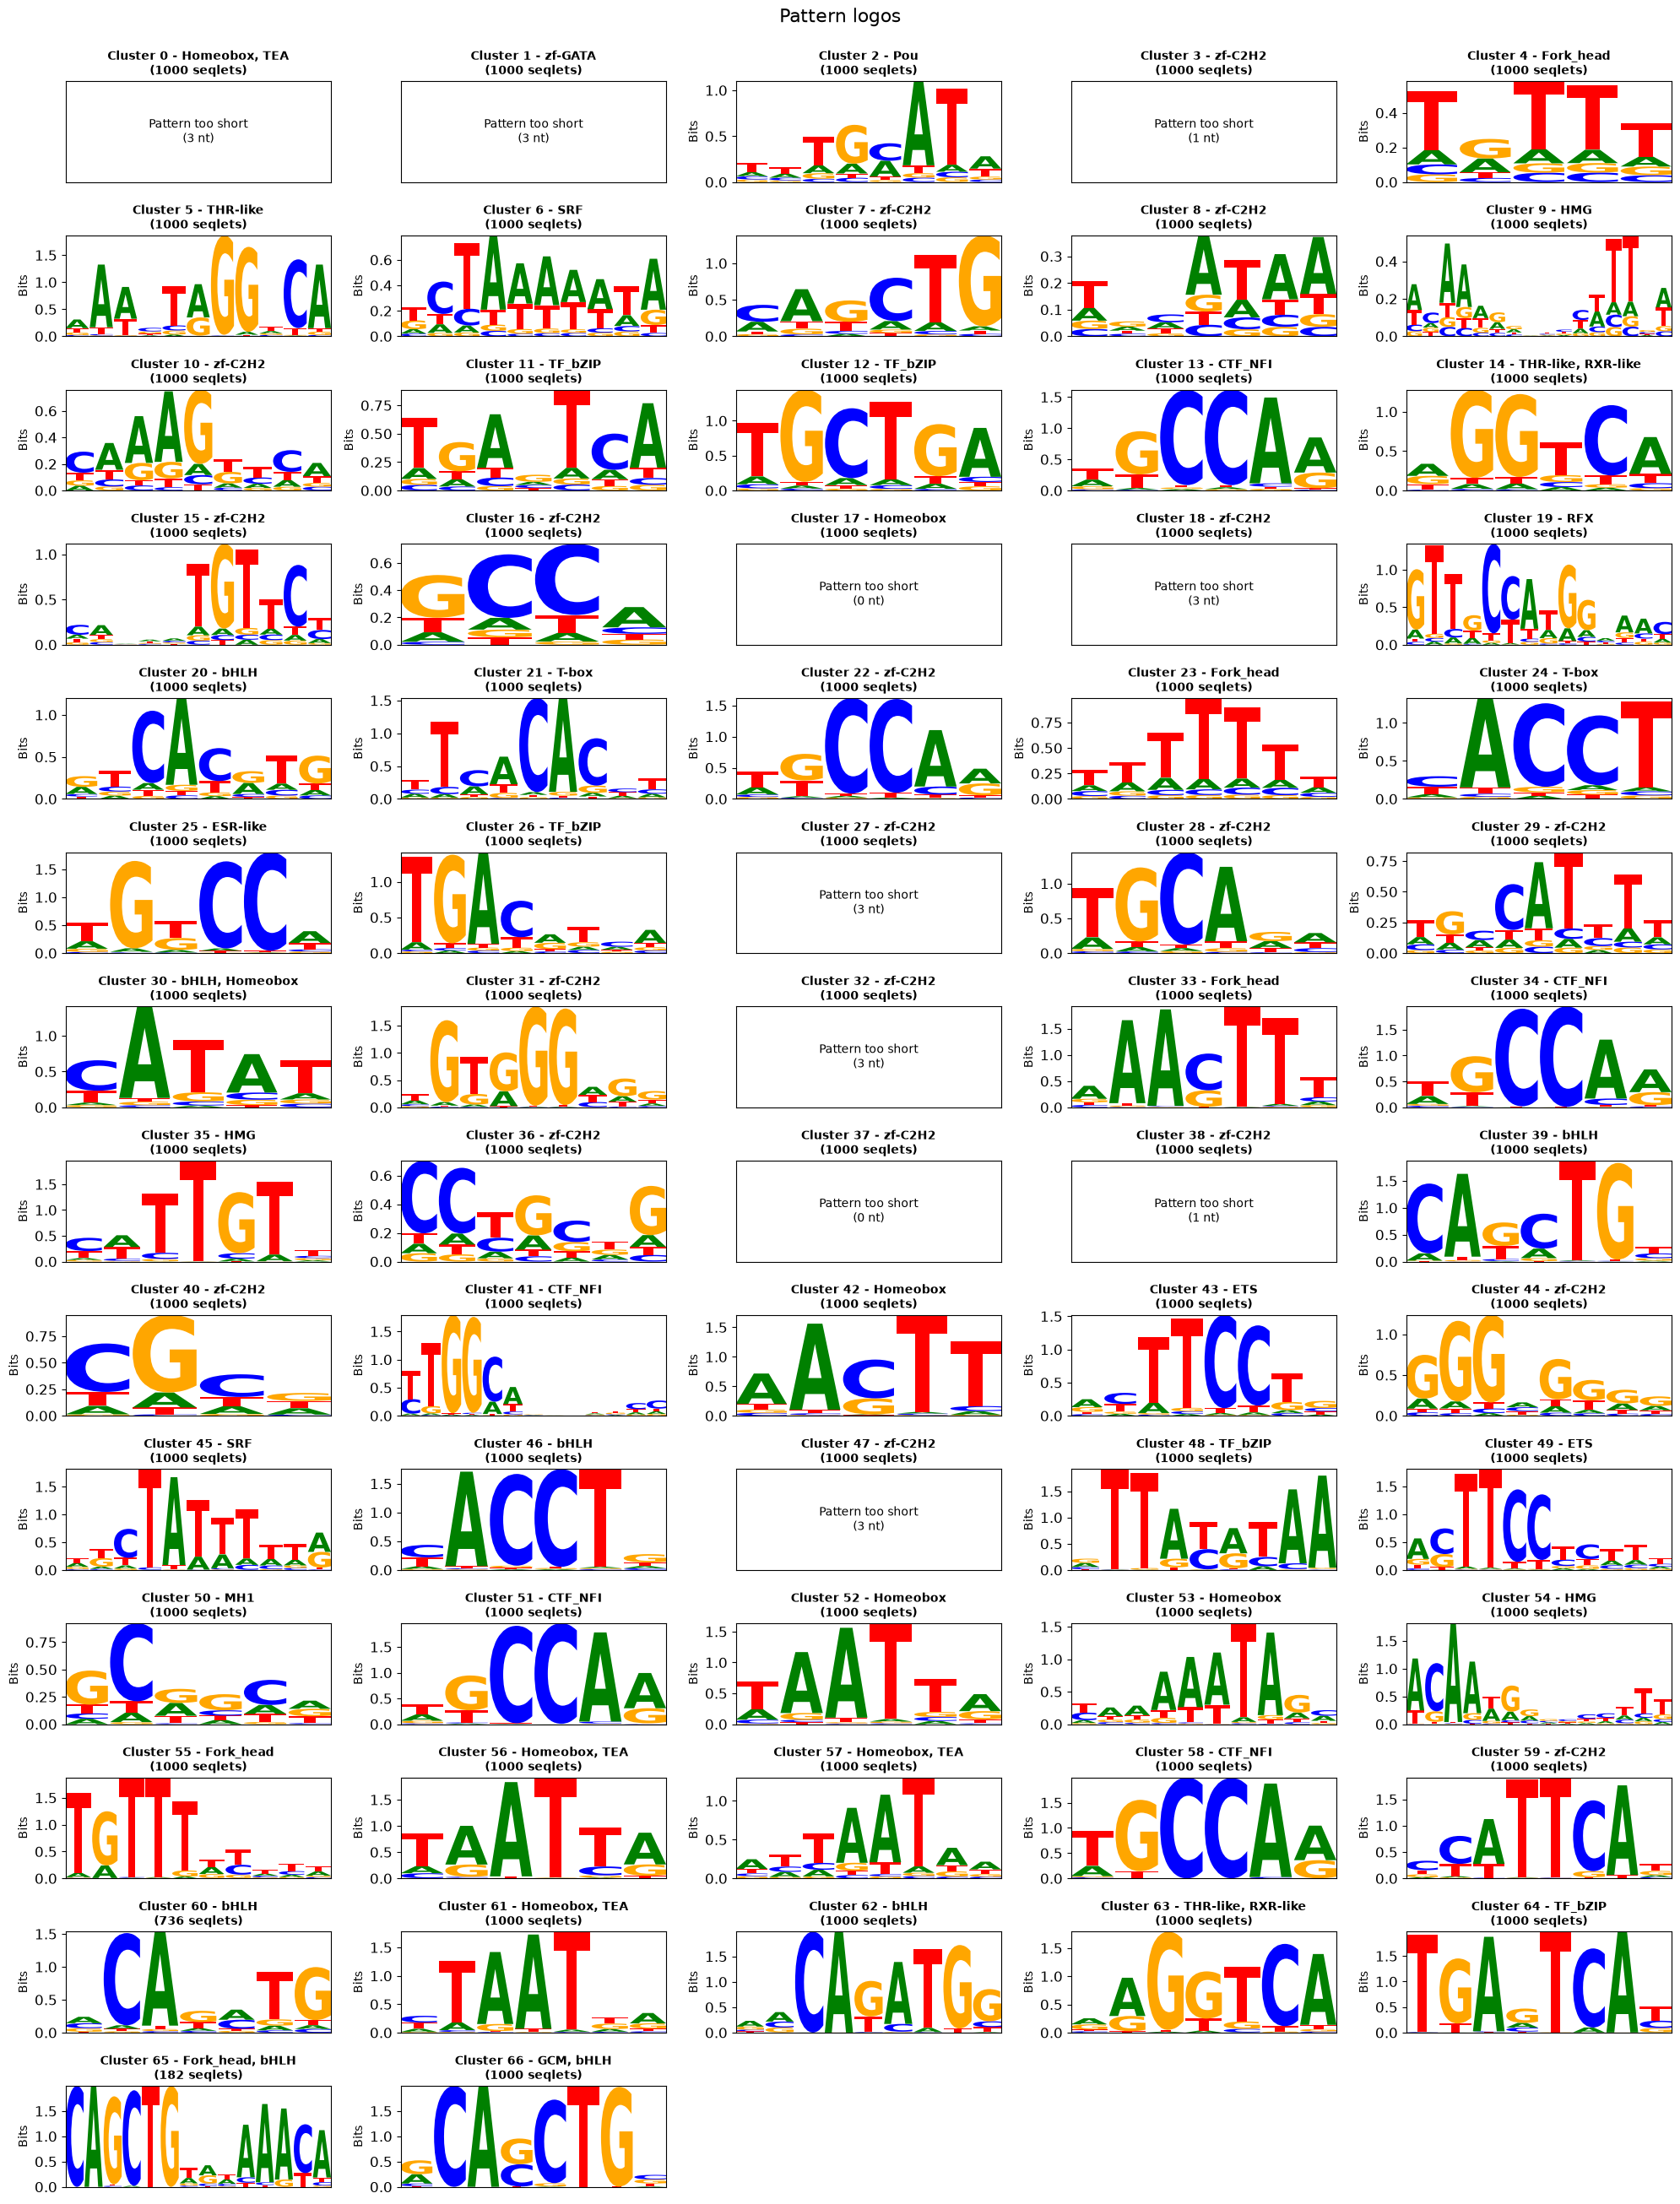

In [8]:
# The figure is sized from the grid, so width/height only need setting to override it.
tm.pl.pattern_logos(
    patterns,
    sort_by="cluster_id",  # or "ic" / "n_seqlets"
    ncols=5,
    ic_threshold=0.2,  # nucleotides in pattern below this will be trimmed
    min_nucleotides=4,  # ignore trimmed patterns less than 4 nucleotides (heterogeneous clusters)
)

Several clusters usually map to the same TF family. Passing `group_by="annotation"` keeps one
representative logo per family, which is a quicker way to see which families are present.

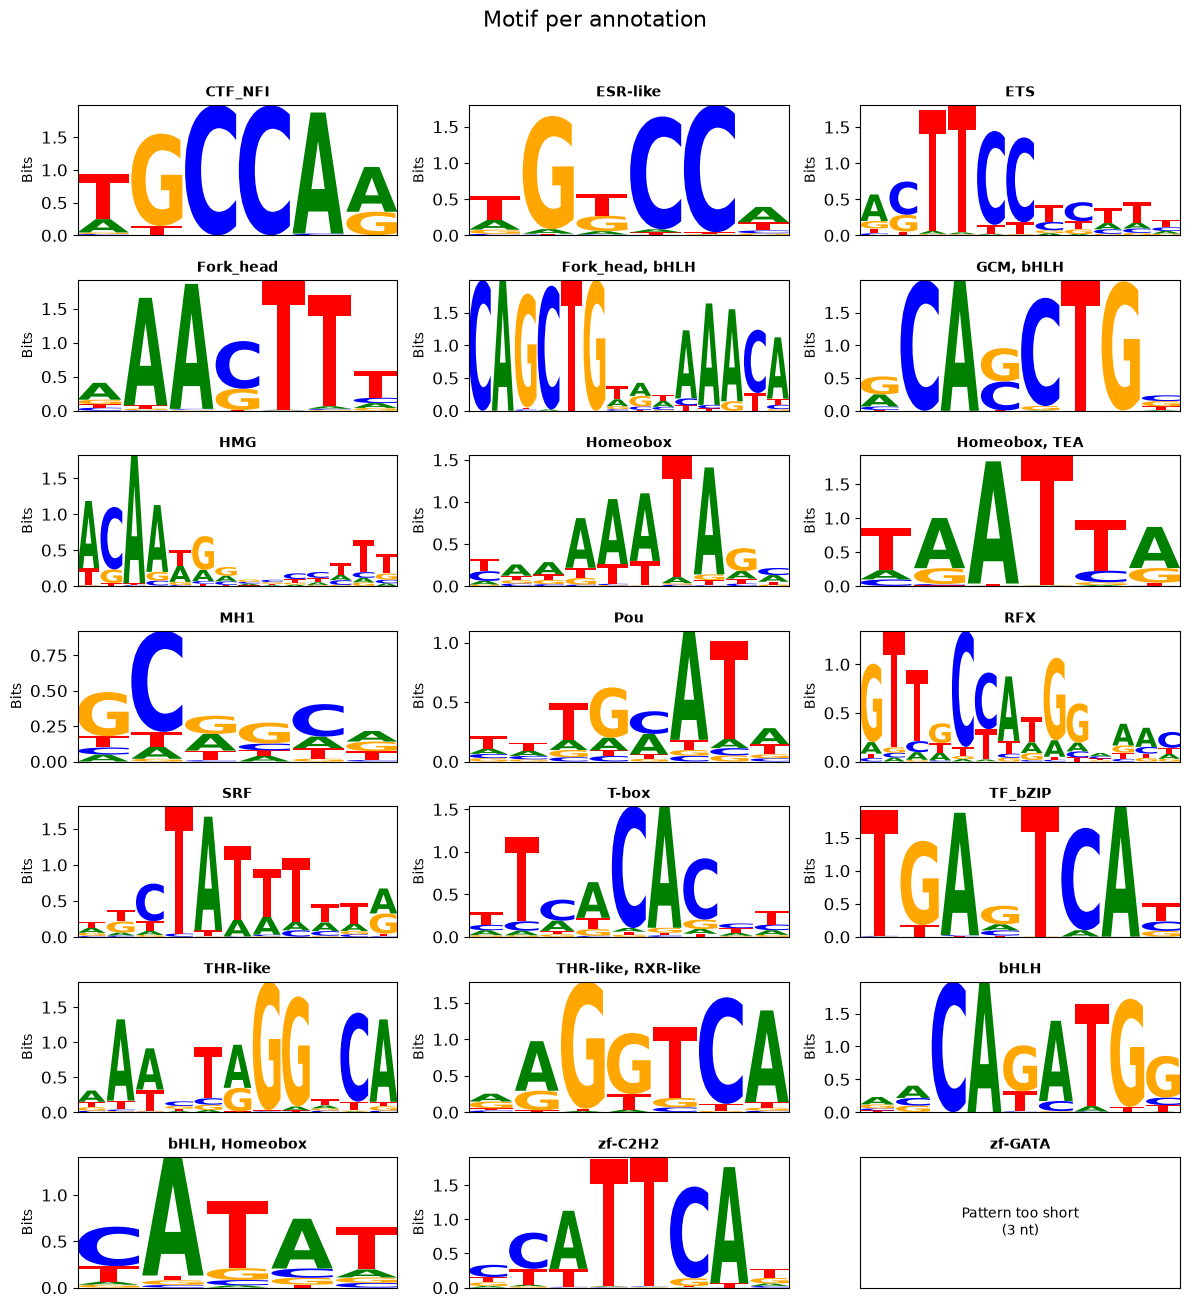

In [9]:
tm.pl.pattern_logos(
    patterns,
    group_by="annotation",
    ncols=3,
    ic_threshold=0.2,
    min_nucleotides=4,
)

And the other way round: all clusters assigned to one family, to judge whether the clustering
found genuine motif variants or simply over-clustered it.

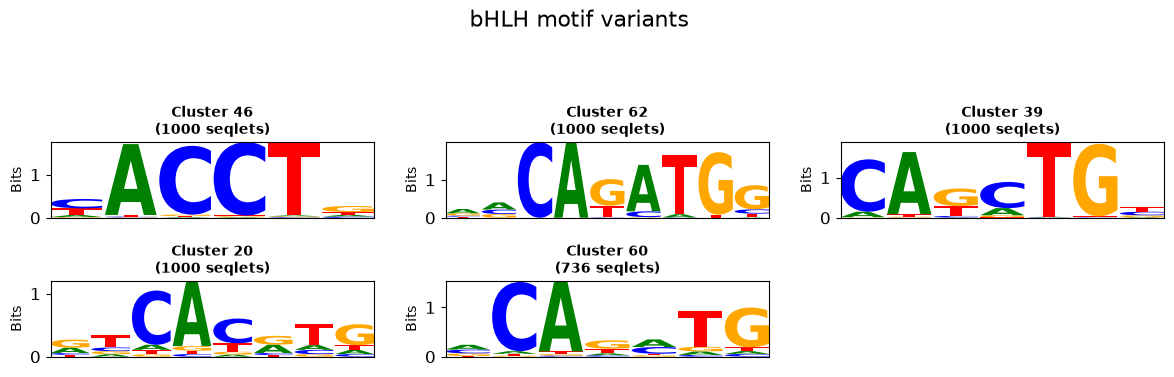

In [10]:
tm.pl.pattern_logos(
    patterns,
    annotation="bHLH",
    sort_by="n_seqlets",
    ncols=3,
    ic_threshold=0.2,
    min_nucleotides=4,
)

### And on the t-SNE

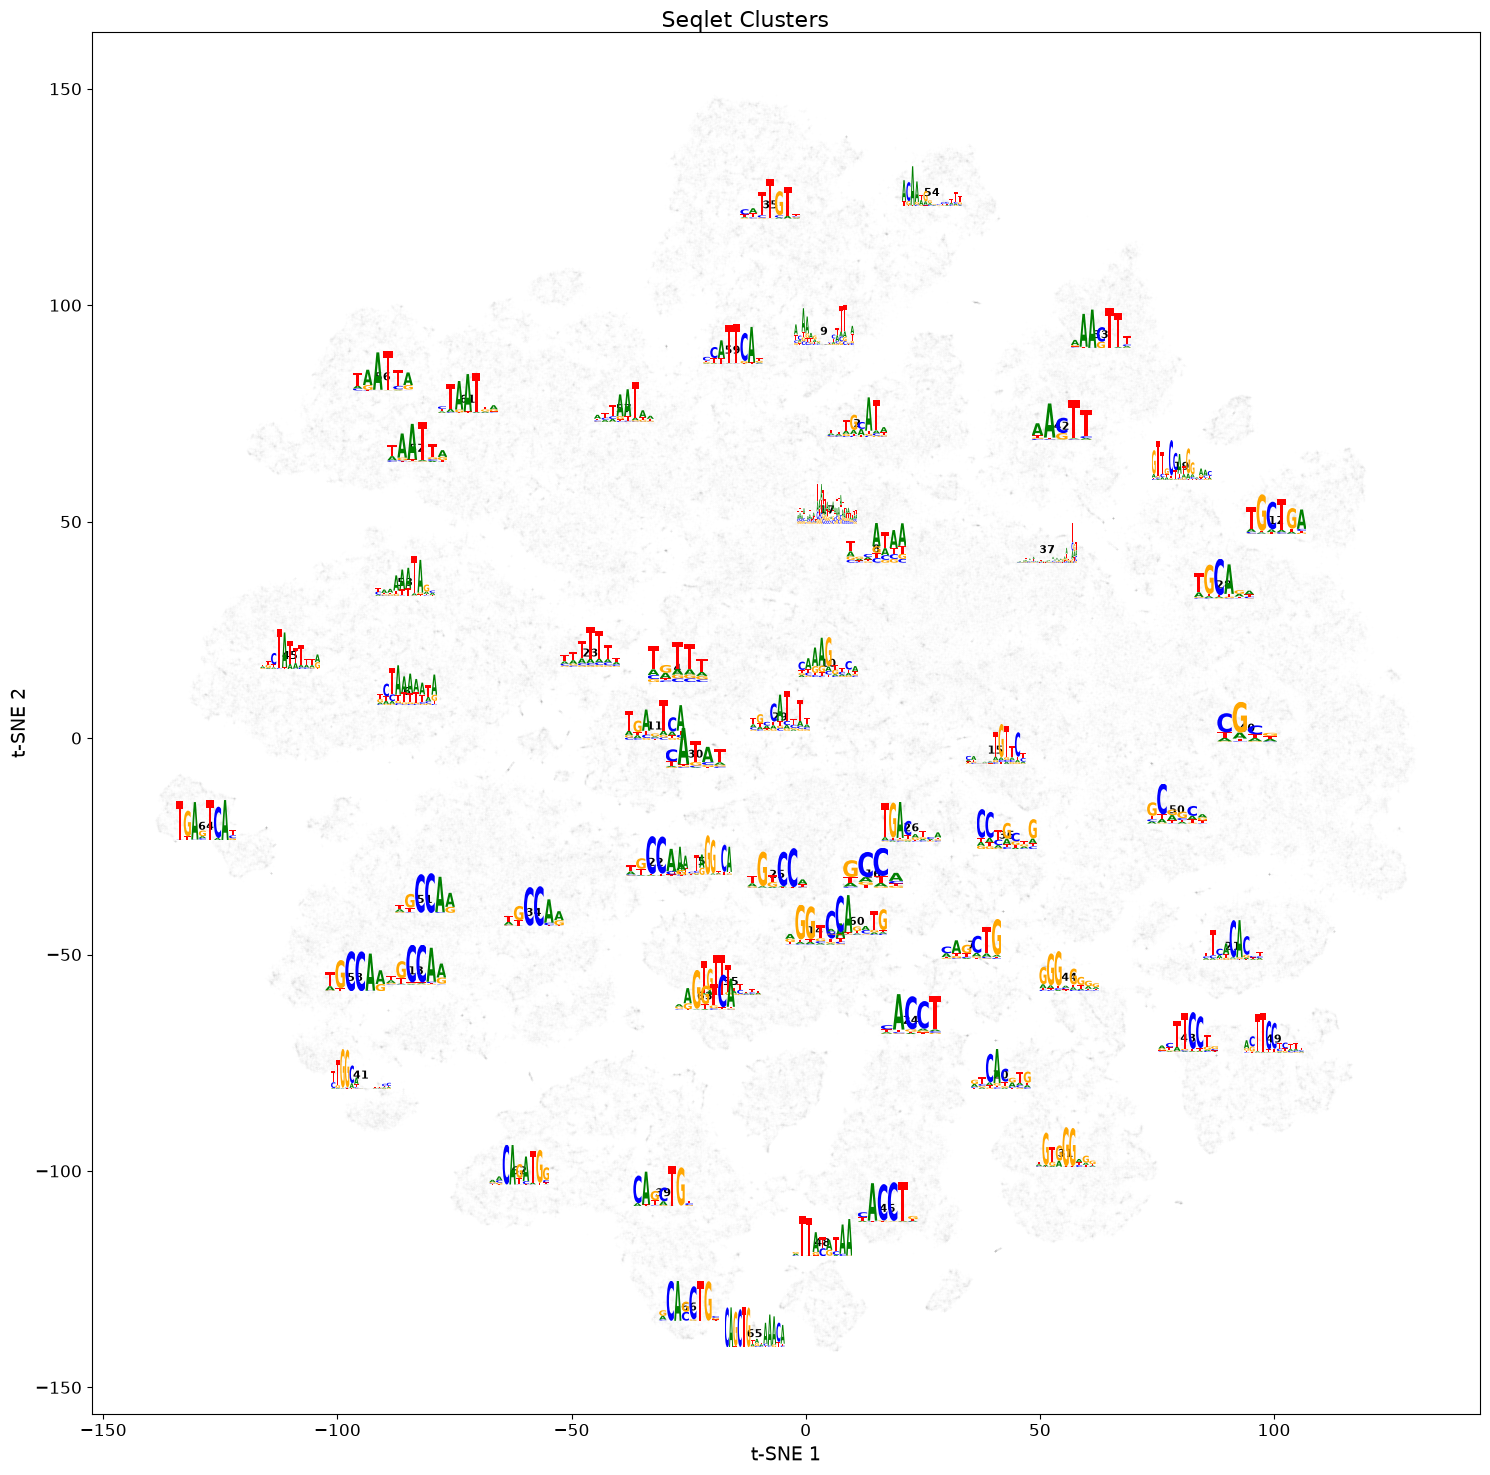

In [11]:
tm.pl.tsne_logos(
    adata,
    patterns,
    color_by=f"predicted_{res}_predicted_family_reranked",
    gray_background=True,  # ignore cmap and make all points gray for better pattern visibility
    min_nucleotides=4,  # ignore trimmed patterns less than 4 nucleotides (heterogeneous clusters)
    width=15,
    height=15,
    s=0.3,
    alpha=0.01,  # background alpha
    logo_height=0.4,
    logo_width=0.6,
    ic_threshold=0.2,  # nucleotides in pattern below this will be trimmed
    min_seqlets=10,  # ignore patterns with less than this many seqlets in the cluster
)

### TF-family usage per cell type

TF families can also be summarised per **cell type**: every region came from a cell-type-specific
enhancer, and we know which seqlets came from which region, so counting family assignments per cell
type shows the family-cell type relationship. {func}`~tfmindi.pl.dbd_heatmap` plots it.

/data/groups/vib.ai/stein.aerts/dabaffy/software/TF-MInDi/src/tfmindi/pl/_utils.py:140: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  fig.tight_layout()


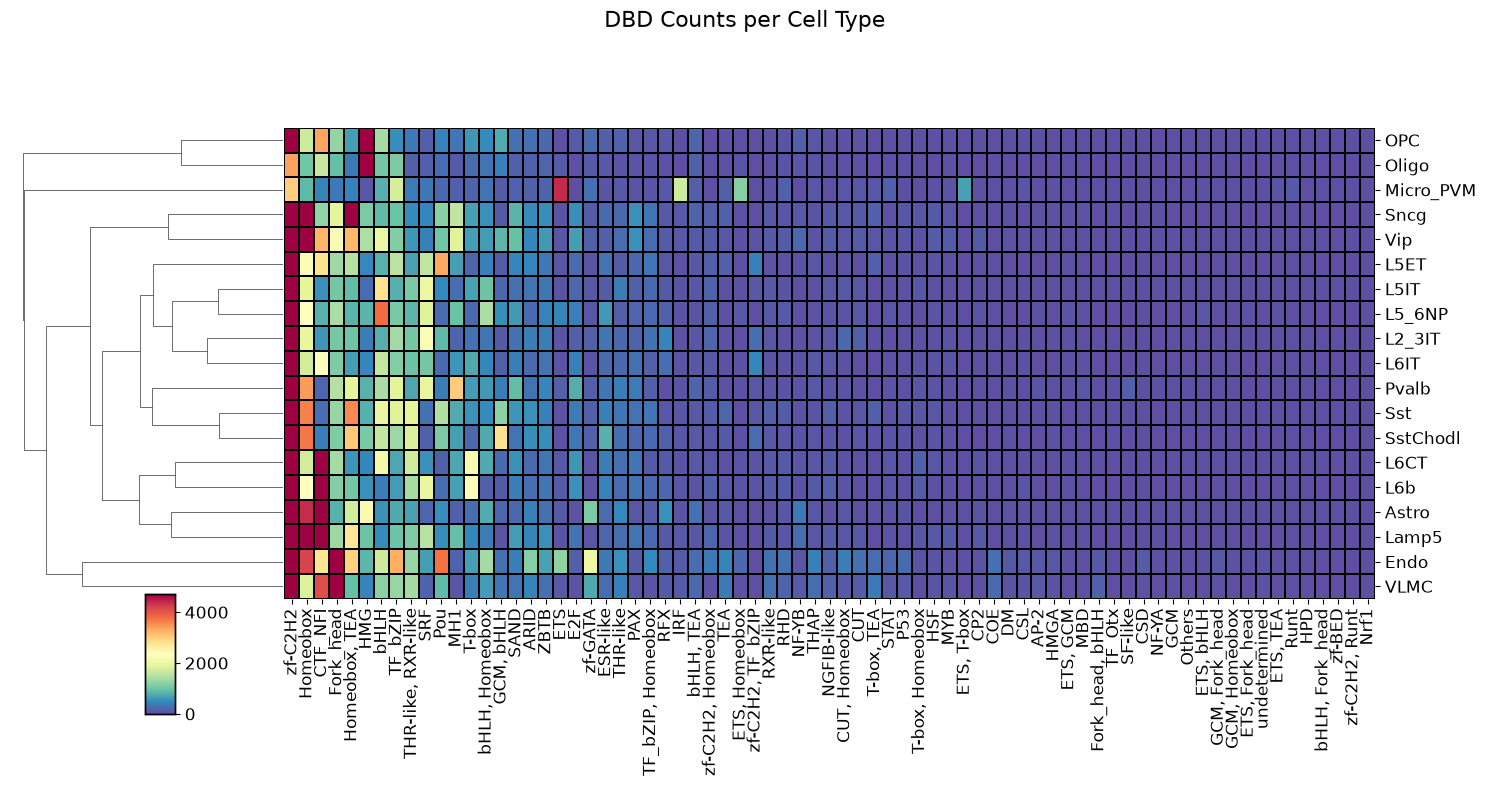

In [12]:
tm.pl.dbd_heatmap(
    adata,
    annotation_col=f"predicted_{res}_predicted_family_reranked",
    width=15,
    x_label_rotation=90,
    standard_scale=False,  # set to True to normalize rows accross cell types
    col_cluster=False,  # turn of the DBD clustering
)

## Annotating regions

Since annotations are per seqlet, we can annotate the full regions the seqlets were extracted from
with {func}`~tfmindi.pl.region_contributions`.

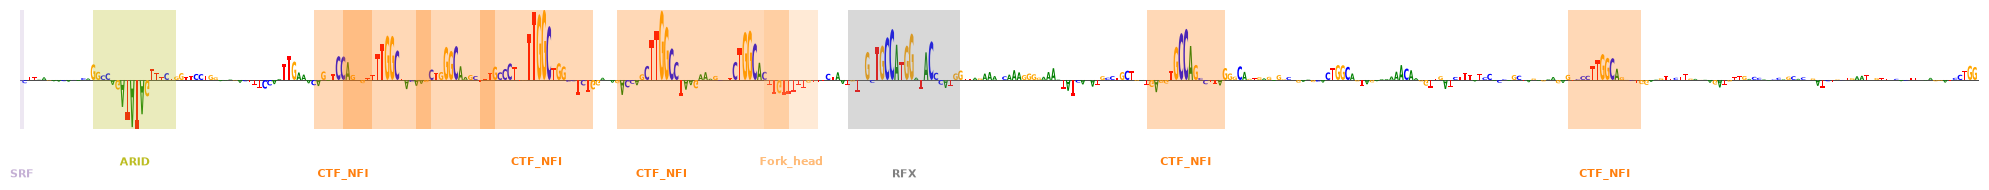

In [13]:
example_idx = 1  # random region idx
tm.pl.region_contributions(
    adata,
    annotation_col=f"predicted_{res}_predicted_family_reranked",
    example_idx=example_idx,
    zoom_start=900,
    zoom_end=1300,  # focus on center 400bp
    min_attribution=2,  # ignore seqlets below this (absolute) threshold
    height=2,
    width=20,
)

## Saving

Tutorials 03 and 04 start from this clustered object.

In [14]:
tm.save_h5ad(adata, "tutorial_data/seqlets_clustered.h5ad")